In [6]:
!pip install pystac_client
import pystac_client

catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1/"
)
search = catalog.search(collections=["era5-pds"], datetime="1980-01")
items = search.get_all_items()

len(items)

2

In [3]:
import planetary_computer

In [9]:


import pystac_client
import xarray as xr
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1/"
)
search = catalog.search(
    collections=["era5-pds"], datetime="2020-01", query={"era5:kind": {"eq": "an"}}
)
items = search.get_all_items()

print(len(items))



item = items[0]
signed_item = planetary_computer.sign(item)
datasets = [
    xr.open_dataset(asset.href, **asset.extra_fields["xarray:open_kwargs"])
    for asset in signed_item.assets.values()
]

ds = xr.combine_by_coords(datasets, join="exact")
ds

1


<xarray.Dataset> Size: 28GB
Dimensions:                            (lat: 721, lon: 1440, time: 744)
Coordinates:
  * lat                                (lat) float32 3kB 90.0 89.75 ... -90.0
  * lon                                (lon) float32 6kB 0.0 0.25 ... 359.8
  * time                               (time) datetime64[ns] 6kB 2020-01-01 ....
Data variables:
    surface_air_pressure               (time, lat, lon) float32 3GB dask.array<chunksize=(372, 150, 150), meta=np.ndarray>
    sea_surface_temperature            (time, lat, lon) float32 3GB dask.array<chunksize=(372, 150, 150), meta=np.ndarray>
    eastward_wind_at_10_metres         (time, lat, lon) float32 3GB dask.array<chunksize=(372, 150, 150), meta=np.ndarray>
    air_temperature_at_2_metres        (time, lat, lon) float32 3GB dask.array<chunksize=(372, 150, 150), meta=np.ndarray>
    eastward_wind_at_100_metres        (time, lat, lon) float32 3GB dask.array<chunksize=(372, 150, 150), meta=np.ndarray>
    northward_wind_at_10_metres        (time, lat, lon) float32 3GB dask.array<chunksize=(372, 150, 150), meta=np.ndarray>
    northward_wind_at_100_metres       (time, lat, lon) float32 3GB dask.array<chunksize=(372, 150, 150), meta=np.ndarray>
    air_pressure_at_mean_sea_level     (time, lat, lon) float32 3GB dask.array<chunksize=(372, 150, 150), meta=np.ndarray>
    dew_point_temperature_at_2_metres  (time, lat, lon) float32 3GB dask.array<chunksize=(372, 150, 150), meta=np.ndarray>
Attributes:
    institution:  ECMWF
    source:       Reanalysis
    title:        ERA5 forecasts

In [6]:
ds.time

<xarray.DataArray 'time' (time: 744)> Size: 6kB
array(['1980-01-01T00:00:00.000000000', '1980-01-01T01:00:00.000000000',
       '1980-01-01T02:00:00.000000000', ..., '1980-01-31T21:00:00.000000000',
       '1980-01-31T22:00:00.000000000', '1980-01-31T23:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 6kB 1980-01-01 ... 1980-01-31T23:00:00
Attributes:
    standard_name:  time

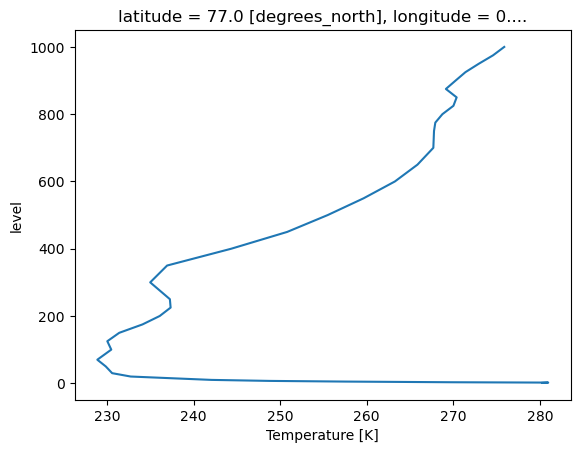

In [1]:
import xarray
era5 = xarray.open_zarr(
    "gs://gcp-public-data-arco-era5/ar/1959-2022-full_37-1h-0p25deg-chunk-1.zarr-v2",
    chunks={'time': 48},
    consolidated=True,
)
era5.sel(time='2021-07-01', latitude=77, longitude=0, method='nearest').temperature.plot(y='level')

In [3]:
era5

<xarray.Dataset> Size: 534TB
Dimensions:                                           (time: 552264,
                                                       latitude: 721,
                                                       longitude: 1440,
                                                       level: 37)
Coordinates:
  * latitude                                          (latitude) float32 3kB ...
  * level                                             (level) int64 296B 1 .....
  * longitude                                         (longitude) float32 6kB ...
  * time                                              (time) datetime64[ns] 4MB ...
Data variables: (12/31)
    10m_u_component_of_wind                           (time, latitude, longitude) float32 2TB dask.array<chunksize=(48, 721, 1440), meta=np.ndarray>
    10m_v_component_of_wind                           (time, latitude, longitude) float32 2TB dask.array<chunksize=(48, 721, 1440), meta=np.ndarray>
    2m_temperature                                    (time, latitude, longitude) float32 2TB dask.array<chunksize=(48, 721, 1440), meta=np.ndarray>
    angle_of_sub_gridscale_orography                  (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    anisotropy_of_sub_gridscale_orography             (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    geopotential                                      (time, level, latitude, longitude) float32 85TB dask.array<chunksize=(48, 37, 721, 1440), meta=np.ndarray>
    ...                                                ...
    total_precipitation                               (time, latitude, longitude) float32 2TB dask.array<chunksize=(48, 721, 1440), meta=np.ndarray>
    type_of_high_vegetation                           (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    type_of_low_vegetation                            (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    u_component_of_wind                               (time, level, latitude, longitude) float32 85TB dask.array<chunksize=(48, 37, 721, 1440), meta=np.ndarray>
    v_component_of_wind                               (time, level, latitude, longitude) float32 85TB dask.array<chunksize=(48, 37, 721, 1440), meta=np.ndarray>
    vertical_velocity                                 (time, level, latitude, longitude) float32 85TB dask.array<chunksize=(48, 37, 721, 1440), meta=np.ndarray>